In [1]:
import skimage as sk
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from skimage import data
from skimage.filters import threshold_otsu, threshold_multiotsu
from sklearn.cluster import KMeans
from sklearn import mixture
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

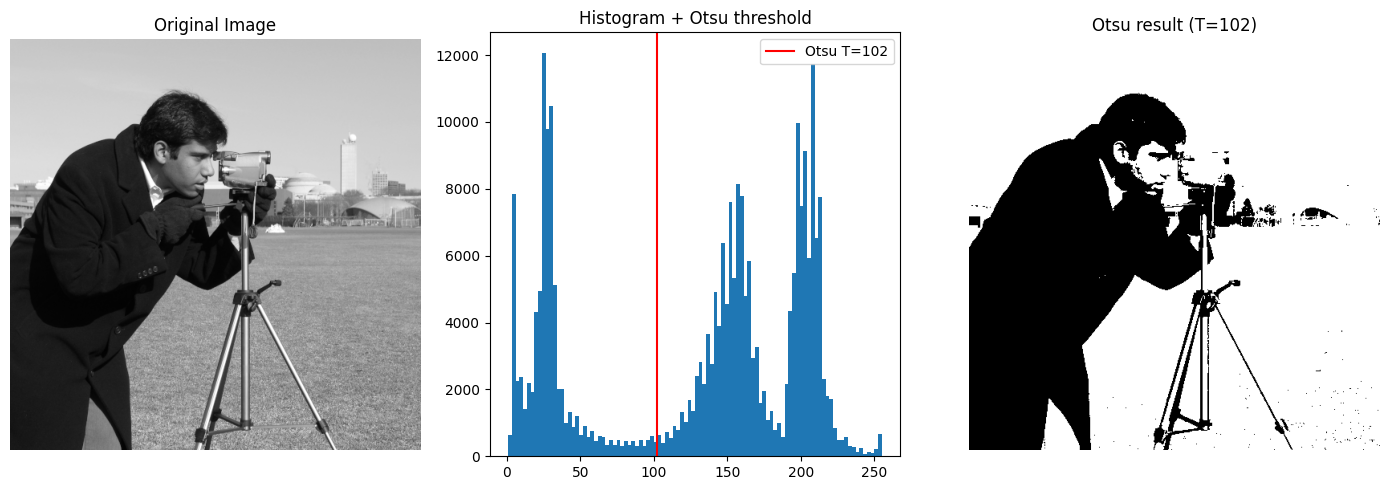

In [2]:
# Task1
I = sk.data.camera()  # grayscale built-in image

flat_data = I.flatten()  # flatten for histogram

# --- Otsu single threshold ---
thresh = threshold_otsu(I)  # finds threshold that maximizes inter-class variance
binary = I > thresh          # pixels above threshold = foreground

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(I, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].hist(flat_data, bins=100, range=[1, flat_data.max()])
axes[1].axvline(thresh, color='r', label=f'Otsu T={thresh}')
axes[1].set_title('Histogram + Otsu threshold')
axes[1].legend()

axes[2].imshow(binary, cmap='gray')
axes[2].set_title(f'Otsu result (T={thresh})')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Otsu's method finds the threshold that maximizes the inter-class variance between foreground and background pixels.
It works well when the image histogram has two clear peaks (bimodal). For the camera image, the cameraman (dark) is
well separated from the sky (bright). Multi-Otsu extends this to multiple thresholds, which is useful when there are
more than two distinct regions. However, thresholding can fail when illumination is uneven or when the histogram does
not show clear peaks.

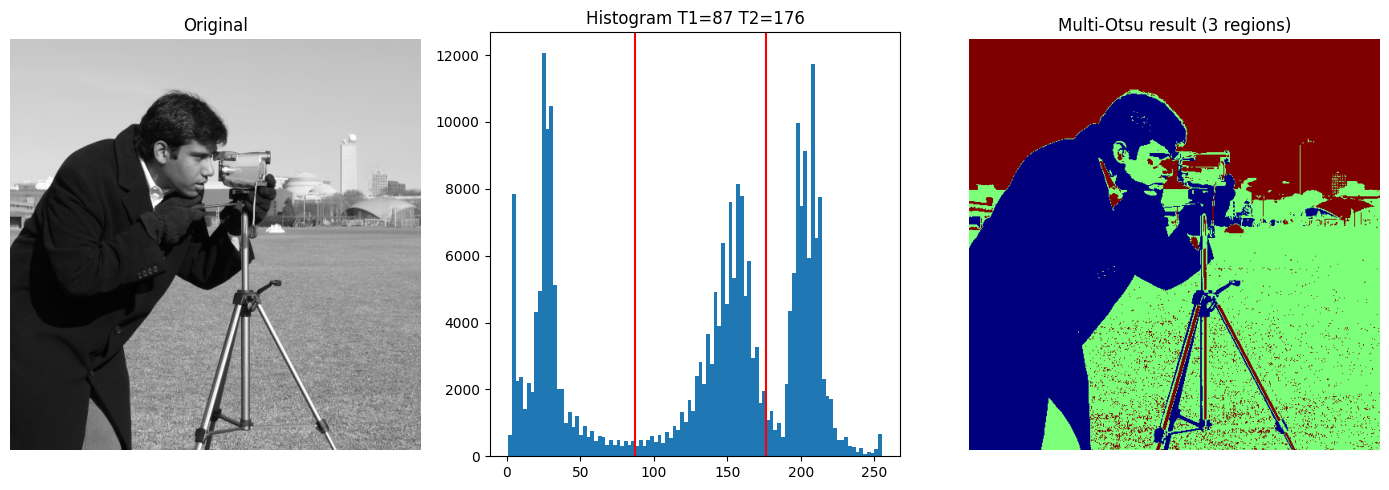

In [4]:
thresholds = threshold_multiotsu(I)       # two thresholds -> three classes
regions = np.digitize(I, bins=thresholds) # assign each pixel to a region

fig, ax = plt.subplots(1, 3, figsize=(14, 5))

ax[0].imshow(I, cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].hist(flat_data, bins=100, range=[1, flat_data.max()])
ax[1].set_title('Histogram T1={} T2={}'.format(thresholds[0], thresholds[1]))
for t in thresholds:
    ax[1].axvline(t, color='r')

ax[2].imshow(regions, cmap='jet')
ax[2].set_title('Multi-Otsu result (3 regions)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

N = 262144 pixels, d = 3 features (RGB channels)


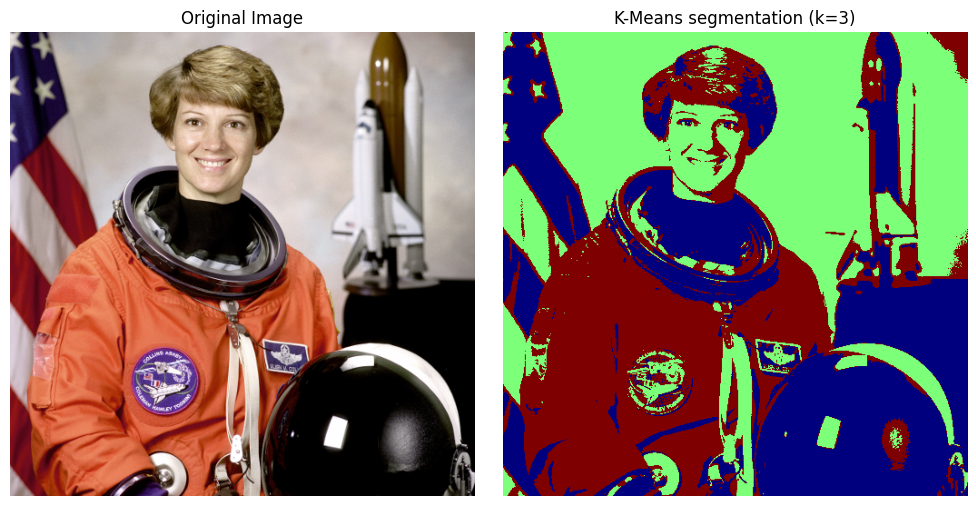

G=1, BIC=8019969.2
G=2, BIC=7627411.0
G=3, BIC=6352599.8
G=4, BIC=6108982.8
G=5, BIC=5696037.7
Best GMM model: G = 5


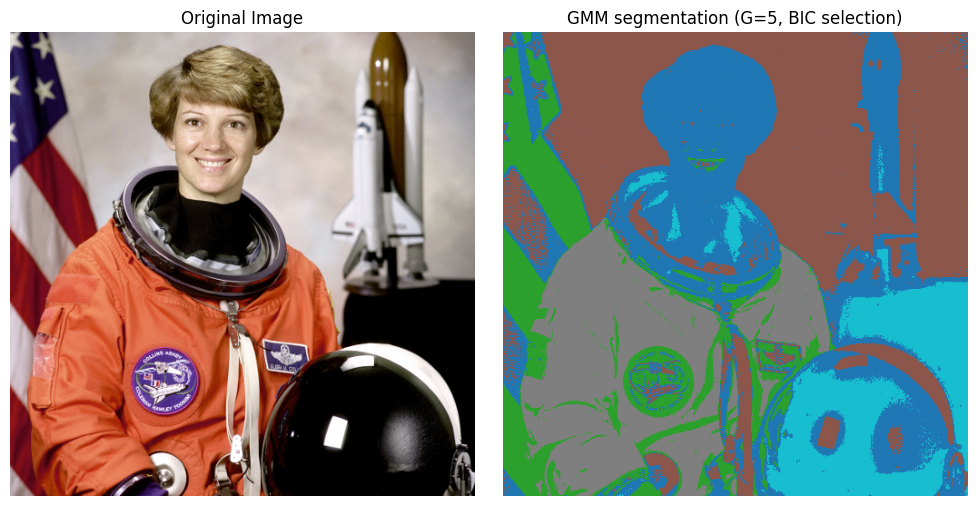

In [5]:
# Task 2
I = sk.data.astronaut()  # RGB image
v_I = np.reshape(I, (I.shape[0]*I.shape[1], I.shape[2]))  # reshape to Npix x 3

print('N = {} pixels, d = {} features (RGB channels)'.format(v_I.shape[0], v_I.shape[1]))

# K-Means with k=3 clusters
n_clus = 3
kmeans = KMeans(n_clusters=n_clus, random_state=0).fit(v_I)  # fit on pixel RGB values
v_kmeans = kmeans.predict(v_I)                                 # assign each pixel to a cluster
I_kmeans = np.reshape(v_kmeans, (I.shape[0], I.shape[1]))     # reshape back to image

fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(I)
ax1.set_title('Original Image')
ax1.set_axis_off()

ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(I_kmeans, cmap='jet')
ax2.set_title(f'K-Means segmentation (k={n_clus})')
ax2.set_axis_off()

plt.tight_layout()
plt.show()

# GMM with BIC model selection
NMAX = 5  # test up to 5 components
bic = []

for kG in np.arange(1, NMAX+1):
    gmm = mixture.GaussianMixture(n_components=kG, covariance_type='full').fit(v_I)
    bic.append(gmm.bic(v_I))  # lower BIC = better model
    print(f'G={kG}, BIC={bic[-1]:.1f}')

idx_winner = np.argmin(bic)  # pick model with lowest BIC
print('Best GMM model: G = {}'.format(idx_winner+1))

# fit the best model and predict
gmm_win = mixture.GaussianMixture(n_components=idx_winner+1, covariance_type='full').fit(v_I)
v_gmm = gmm_win.fit_predict(v_I)
I_gmm = np.reshape(v_gmm, (I.shape[0], I.shape[1]))

fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(I)
ax1.set_title('Original Image')
ax1.set_axis_off()

ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(I_gmm, cmap='tab10')
ax2.set_title('GMM segmentation (G={}, BIC selection)'.format(idx_winner+1))
ax2.set_axis_off()

plt.tight_layout()
plt.show()

**Comments:**

K-Means groups pixels into k clusters based on their RGB color distance to centroids.
The number of clusters k must be chosen manually, which is a limitation.
GMM is a probabilistic extension: it models the pixel distribution as a mixture of Gaussians, and BIC helps us select
the optimal number of components automatically (lowest BIC wins).
Both methods are unsupervised — they require no labeled data, but the result may not match meaningful semantic regions.

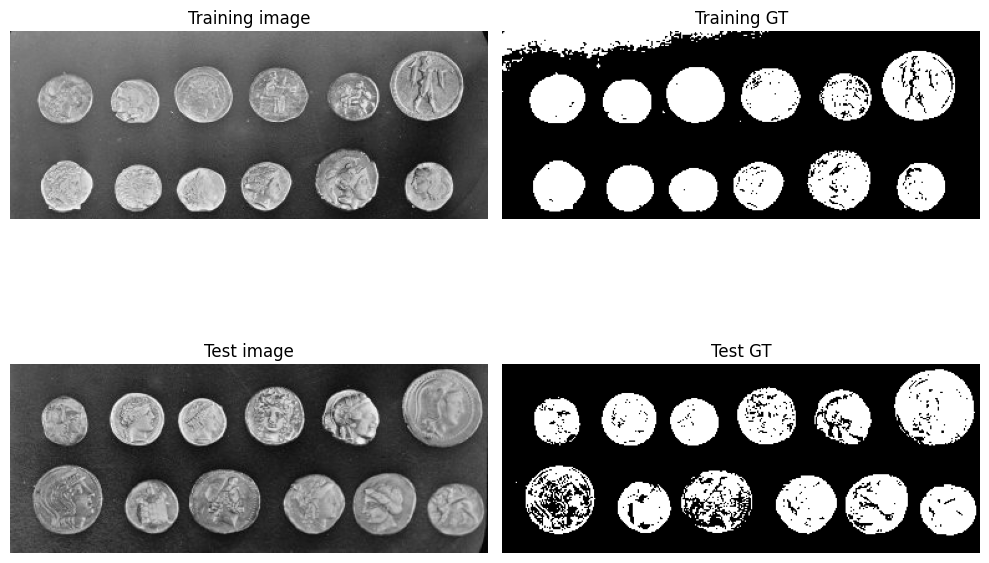

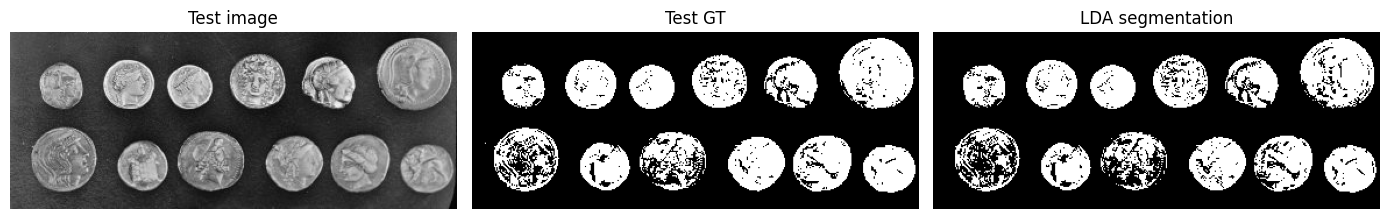

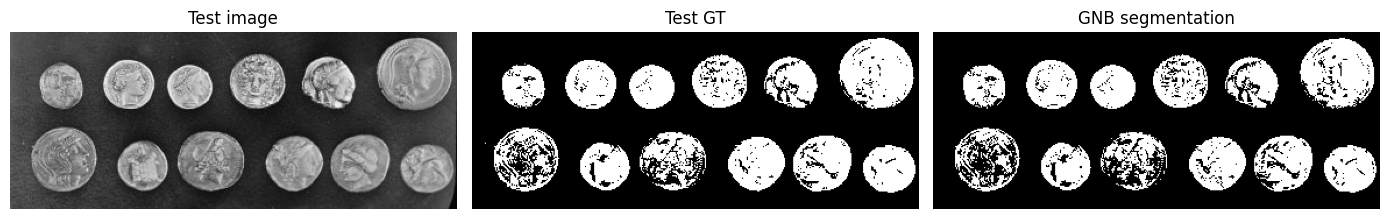

LDA: TPR=0.9244, FPR=0.0000, DSC=0.9607
GNB: TPR=0.9380, FPR=0.0000, DSC=0.9680

LDA Confusion Matrix:
 [[40460     0]
 [ 1354 16554]]
GNB Confusion Matrix:
 [[40460     0]
 [ 1110 16798]]


In [6]:
# Task 3
# use coins image - grayscale, clear foreground/background
I_full = sk.data.coins()

# split into train (top half) and test (bottom half) -- simulates train/test split like the lecture
mid = I_full.shape[0] // 2
I_train = I_full[:mid, :]  # top half
I_test  = I_full[mid:, :]  # bottom half

# create ground truth using Otsu on train image (simulates expert annotation)
thresh_gt = threshold_otsu(I_train)
I_train_GT = (I_train > thresh_gt).astype(np.uint8)  # 1=coin, 0=background
I_test_GT  = (I_test  > thresh_gt).astype(np.uint8)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0,0].imshow(I_train, cmap='gray'); axes[0,0].set_title('Training image'); axes[0,0].axis('off')
axes[0,1].imshow(I_train_GT, cmap='gray'); axes[0,1].set_title('Training GT'); axes[0,1].axis('off')
axes[1,0].imshow(I_test, cmap='gray'); axes[1,0].set_title('Test image'); axes[1,0].axis('off')
axes[1,1].imshow(I_test_GT, cmap='gray'); axes[1,1].set_title('Test GT'); axes[1,1].axis('off')
plt.tight_layout()
plt.show()

# reshape train/test as 1D arrays (Npix x 1 feature = intensity)
v_I_train = I_train.reshape(I_train.shape[0]*I_train.shape[1], 1).astype(np.float64)
v_I_test  = I_test.reshape(I_test.shape[0]*I_test.shape[1], 1).astype(np.float64)
v_train_GT = I_train_GT.reshape(-1)  # flat ground truth labels
v_test_GT  = I_test_GT.reshape(-1)

# --- LDA classifier ---
lda_model = LinearDiscriminantAnalysis(store_covariance=True)
lda_model.fit(v_I_train, v_train_GT)  # train on training image + GT
v_lda = lda_model.predict(v_I_test)  # predict on test image
I_lda = v_lda.reshape(I_test.shape[0], I_test.shape[1]).astype(np.uint8)

fig, ax = plt.subplots(1, 3, figsize=(14, 5))
ax[0].imshow(I_test, cmap='gray'); ax[0].set_title('Test image'); ax[0].axis('off')
ax[1].imshow(I_test_GT, cmap='gray'); ax[1].set_title('Test GT'); ax[1].axis('off')
ax[2].imshow(I_lda, cmap='gray'); ax[2].set_title('LDA segmentation'); ax[2].axis('off')
plt.tight_layout()
plt.show()

# --- Gaussian Naive Bayes classifier ---
gnb_model = GaussianNB()
gnb_model.fit(v_I_train, v_train_GT)  # train
v_gnb = gnb_model.predict(v_I_test)  # predict
I_gnb = v_gnb.reshape(I_test.shape[0], I_test.shape[1]).astype(np.uint8)

fig, ax = plt.subplots(1, 3, figsize=(14, 5))
ax[0].imshow(I_test, cmap='gray'); ax[0].set_title('Test image'); ax[0].axis('off')
ax[1].imshow(I_test_GT, cmap='gray'); ax[1].set_title('Test GT'); ax[1].axis('off')
ax[2].imshow(I_gnb, cmap='gray'); ax[2].set_title('GNB segmentation'); ax[2].axis('off')
plt.tight_layout()
plt.show()

# --- Performance evaluation (same as lecture) ---
def evaluate(name, v_pred, v_gt):
    CM = confusion_matrix(v_gt, v_pred.astype(bool))  # confusion matrix
    tn, fp, fn, tp = CM.ravel()
    TPR = tp / (tp + fn)           # sensitivity
    FPR = fp / (fp + tn)           # 1 - specificity
    DSC = 2*tp / (2*tp + fp + fn)  # Dice similarity coefficient
    print(f'{name}: TPR={TPR:.4f}, FPR={FPR:.4f}, DSC={DSC:.4f}')
    return CM

CM_lda = evaluate('LDA', v_lda, v_test_GT)
CM_gnb = evaluate('GNB', v_gnb, v_test_GT)

print('\nLDA Confusion Matrix:\n', CM_lda)
print('GNB Confusion Matrix:\n', CM_gnb)

Supervised methods (LDA, GNB) use ground truth labels to learn the pixel intensity distribution of each class.
LDA finds a linear decision boundary between classes, while GNB models each class as a Gaussian and applies Bayes rule.
Both are trained on the top half of the image and tested on the bottom half.
TPR (sensitivity) measures how many real foreground pixels are correctly detected.
FPR measures false alarms. DSC (Dice) summarizes overall overlap — closer to 1 is better.
The main limitation here is that we only use pixel intensity as feature, which may not be enough in complex images.
With more features (texture, context) the classifiers would perform better.

## **Task 4**

### Unsupervised Segmentation

- Does **not** require labeled data
- Groups pixels based on similarity (color, intensity, texture)
- Examples from lecture: **K-Means**, **GMM + BIC**
- **Advantages:** simple, no annotation cost, works out of the box
- **Disadvantages:** no semantic meaning guaranteed, number of clusters must be set (K-Means),
result may differ each run, sensitive to noise

### Supervised Segmentation

- **Requires** labeled data (ground truth annotations per pixel)
- Trains a classifier to predict labels: each pixel is a sample, its features (intensity, RGB) are inputs
- Examples from lecture: **LDA**, **QDA**, **Gaussian Naive Bayes**, Random Forest
- **Advantages:** more accurate when enough labeled data is available, result has clear semantic meaning
- **Disadvantages:** requires expensive manual annotation, may not generalize to unseen images

### Example

- **Unsupervised:** K-Means on the astronaut image groups pixels by RGB similarity into 3 color clusters.
No one told the algorithm what 'face', 'suit' or 'background' means — it just found color groups.
- **Supervised:** LDA trained on the coins image with a GT mask learns what intensity range corresponds to coins.
It then applies this knowledge to segment a new image — like how the professor used retinal vessel GT images to train classifiers.